# Phase 8 Drift Evidence Exploration

This notebook inspects the existing simple-model drift evidence in `development/math_fidelity/logs/`. It treats the generated logs as the source of truth and does not rerun simulations by default.

Path handling is intentionally portable: the notebook can be run from the repository root or from `development/math_fidelity/`, where the notebook file lives.

## 1. Load Generated Logs

Load the compact run-level table and the long-format time-series table with pandas. If this cell fails with `ModuleNotFoundError: pandas`, use a notebook kernel with pandas installed. The production app runtime does not need pandas.

The setup cell below locates the evidence-lab root before constructing log paths; later cells should use `LOG_DIR` rather than hard-coded repository-relative paths.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/double_pendulum_math_fidelity_mpl")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp/double_pendulum_math_fidelity_cache")
import matplotlib.pyplot as plt

def find_lab_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, start / "development" / "math_fidelity"]
    candidates.extend(parent / "development" / "math_fidelity" for parent in start.parents)
    for candidate in candidates:
        if (
            (candidate / "logs").is_dir()
            and (candidate / "BASELINE_REVIEW.md").is_file()
            and (candidate / "DRIFT_INVESTIGATION.md").is_file()
        ):
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate development/math_fidelity. Run this notebook from the repository root "
        "or from the evidence-lab directory."
    )

LAB_ROOT = find_lab_root()
LOG_DIR = LAB_ROOT / "logs"
REPORT_DIR = LAB_ROOT / "reports"
FIGURE_DIR = LAB_ROOT / "reports" / "figures"
SAVE_FIGURES = False

runs = pd.read_csv(LOG_DIR / "simple_drift_results.csv")
timeseries = pd.read_csv(LOG_DIR / "timeseries" / "simple_drift_timeseries_long.csv")

SOLVER_ORDER = ["solve_ivp_default", "rk45_strict", "dop853_strict", "dop853_reference"]
SOLVER_LABELS = {
    "solve_ivp_default": "default",
    "rk45_strict": "RK45 strict",
    "dop853_strict": "DOP853 strict",
    "dop853_reference": "DOP853 reference",
}

print("evidence lab:", LAB_ROOT)
print("run-level rows/columns:", runs.shape)
print("time-series rows/columns:", timeseries.shape)
runs.head()

evidence lab: /Users/Ian/Documents/Study/ComputerScience/Maxima/MS327/Python/Double_Pendulum_App/development/math_fidelity
run-level rows/columns: (16, 31)
time-series rows/columns: (10400, 29)


,case_name,case_description,solver_config,method,rtol,atol,duration_s,sample_count_requested,sample_count_compared,initial_conditions_user_units,...,max_abs_theta_diff_rad,max_abs_theta_diff_deg,final_theta_diff_rad,final_theta_diff_deg,max_bob_position_abs_diff,divergence_time_s_by_theta_threshold_rad,lagrangian_max_abs_energy_drift,hamiltonian_max_abs_energy_drift,lagrangian_final_energy_drift,hamiltonian_final_energy_drift
0,low_energy_small_angles,Small angles released from rest; expected to b...,solve_ivp_default,solve_ivp_default,NaN,NaN,4.0,800,800,"[5.0,7.0,0.0,0.0]",...,2.056212e-04,1.178123e-02,"[5.4762034716049346e-05,-8.73492366082057e-05]","[0.003137633466778523,-0.0050047426013398125]",1.589037e-04,"{""0.001"":null,""0.01"":null,""0.1"":null}",9.831632e-05,1.007176e-04,-6.951960e-05,-4.872075e-05
1,low_energy_small_angles,Small angles released from rest; expected to b...,rk45_strict,RK45,1.000000e-08,1.000000e-10,4.0,800,800,"[5.0,7.0,0.0,0.0]",...,3.266163e-10,1.871374e-08,"[-1.3362858042320624e-10,-5.235809008574677e-11]","[-7.656353680574214e-09,-2.9998975852790484e-09]",4.635515e-10,"{""0.001"":null,""0.01"":null,""0.1"":null}",3.536748e-09,3.822709e-09,-3.536748e-09,-3.822709e-09
2,low_energy_small_angles,Small angles released from rest; expected to b...,dop853_strict,DOP853,1.000000e-09,1.000000e-11,4.0,800,800,"[5.0,7.0,0.0,0.0]",...,8.674636e-10,4.970200e-08,"[1.2725621945097743e-10,-1.8096055209859685e-10]","[7.29124429133162e-09,-1.0368275893606851e-08]",6.038422e-10,"{""0.001"":null,""0.01"":null,""0.1"":null}",4.221832e-10,4.813145e-10,-8.373746e-12,-2.147260e-11
3,low_energy_small_angles,Small angles released from rest; expected to b...,dop853_reference,DOP853,1.000000e-11,1.000000e-13,4.0,800,800,"[5.0,7.0,0.0,0.0]",...,1.018527e-11,5.835729e-10,"[1.5418083476603783e-12,-2.156191891700132e-12]","[8.833911113897881e-11,-1.2354069521474665e-10]",6.227532e-12,"{""0.001"":null,""0.01"":null,""0.1"":null}",4.192202e-12,4.288125e-12,-5.684342e-14,-1.172396e-13
4,screenshot_like_simple_start,App preset-style simple case mentioned in hist...,solve_ivp_default,solve_ivp_default,NaN,NaN,4.0,800,800,"[0.0,60.0,0.0,0.0]",...,9.527861e-02,5.459062e+00,"[-0.05499453985495484,0.08335116245799636]","[-3.1509550299529105,4.775669826352464]",6.452911e-02,"{""0.001"":0.425531914893617,""0.01"":2.0025031289...",3.106289e-01,3.941292e-02,3.105160e-01,9.587091e-03


## 2. Data Inventory

Check available cases, solvers, tolerance configurations, row counts, missing values, and basic run coverage before plotting.

In [2]:
inventory = {
    "run_rows": len(runs),
    "timeseries_rows": len(timeseries),
    "cases": sorted(runs["case_name"].unique()),
    "solver_configs": list(runs["solver_config"].drop_duplicates()),
    "methods": list(runs["method"].drop_duplicates()),
}
inventory

{'run_rows': 16,
 'timeseries_rows': 10400,
 'cases': ['higher_energy_wide_swing',
  'low_energy_small_angles',
  'nonzero_velocity_spirograph',
  'screenshot_like_simple_start'],
 'solver_configs': ['solve_ivp_default',
  'rk45_strict',
  'dop853_strict',
  'dop853_reference'],
 'methods': ['solve_ivp_default', 'RK45', 'DOP853']}

In [3]:
tolerances = runs[["solver_config", "method", "rtol", "atol"]].drop_duplicates().sort_values("solver_config")
coverage = runs.groupby(["case_name", "solver_config"]).size().unstack(fill_value=0)
missing_runs = runs.isna().sum().loc[lambda s: s > 0]
missing_timeseries = timeseries.isna().sum().loc[lambda s: s > 0]

display(tolerances)
display(coverage)
print("Missing values in run-level log:")
display(missing_runs)
print("Missing values in time-series log:")
display(missing_timeseries)
print("Time-series rows per run:")
display(timeseries.groupby(["case_name", "solver_config"]).size().unstack(fill_value=0))

,solver_config,method,rtol,atol
3,dop853_reference,DOP853,1.000000e-11,1.000000e-13
2,dop853_strict,DOP853,1.000000e-09,1.000000e-11
1,rk45_strict,RK45,1.000000e-08,1.000000e-10
0,solve_ivp_default,solve_ivp_default,NaN,NaN


solver_config,dop853_reference,dop853_strict,rk45_strict,solve_ivp_default
case_name,,,,
higher_energy_wide_swing,1,1,1,1
low_energy_small_angles,1,1,1,1
nonzero_velocity_spirograph,1,1,1,1
screenshot_like_simple_start,1,1,1,1


Missing values in run-level log:


rtol    4
atol    4
dtype: int64

Missing values in time-series log:


rtol    2600
atol    2600
dtype: int64

Time-series rows per run:


solver_config,dop853_reference,dop853_strict,rk45_strict,solve_ivp_default
case_name,,,,
higher_energy_wide_swing,600,600,600,600
low_energy_small_angles,800,800,800,800
nonzero_velocity_spirograph,400,400,400,400
screenshot_like_simple_start,800,800,800,800


## 3. Summary Visualisations

These plots summarize the run-level evidence. Log-scaled y-axes make the tolerance-driven collapse in drift easier to see.

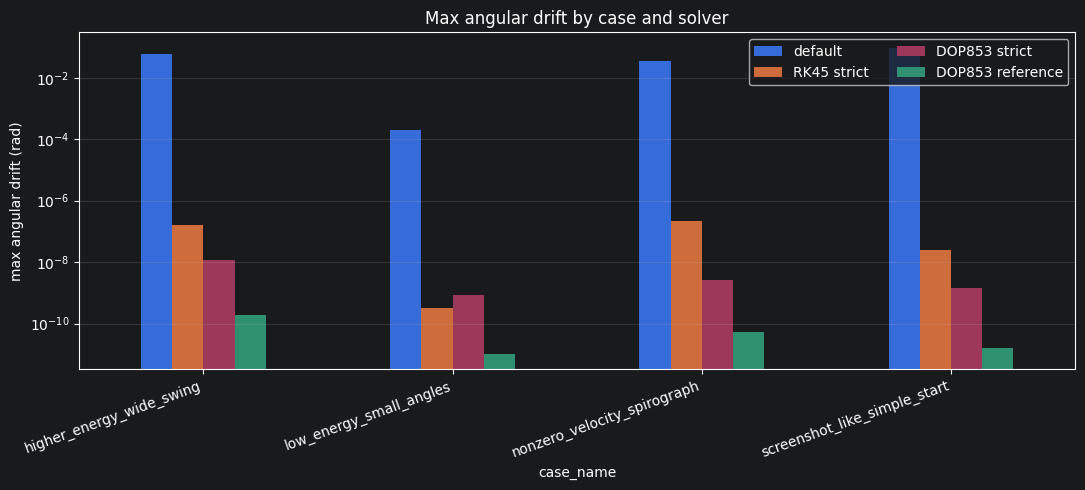

In [4]:
def ordered_bar(metric, ylabel, title):
    pivot = (
        runs.pivot(index="case_name", columns="solver_config", values=metric)
        .reindex(columns=SOLVER_ORDER)
    )
    ax = pivot.plot(kind="bar", figsize=(11, 5), logy=True)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", which="both", alpha=0.25)
    ax.legend([SOLVER_LABELS.get(c, c) for c in pivot.columns], ncols=2)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    return ax

ordered_bar("max_abs_theta_diff_rad", "max angular drift (rad)", "Max angular drift by case and solver");

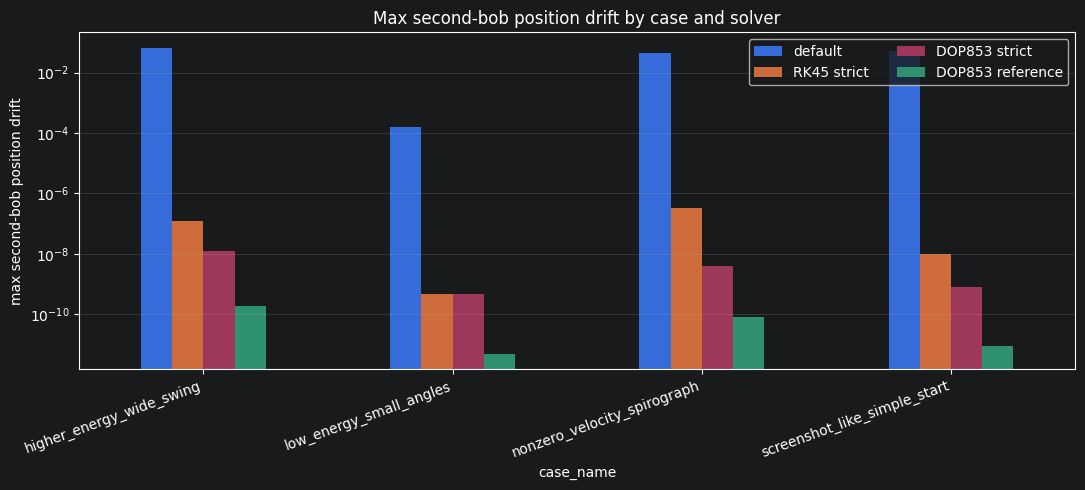

In [5]:
second_bob_summary = (
    timeseries.groupby(["case_name", "solver_config"], as_index=False)["second_bob_position_diff"]
    .max()
    .pivot(index="case_name", columns="solver_config", values="second_bob_position_diff")
    .reindex(columns=SOLVER_ORDER)
)
ax = second_bob_summary.plot(kind="bar", figsize=(11, 5), logy=True)
ax.set_ylabel("max second-bob position drift")
ax.set_title("Max second-bob position drift by case and solver")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend([SOLVER_LABELS.get(c, c) for c in second_bob_summary.columns], ncols=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout();

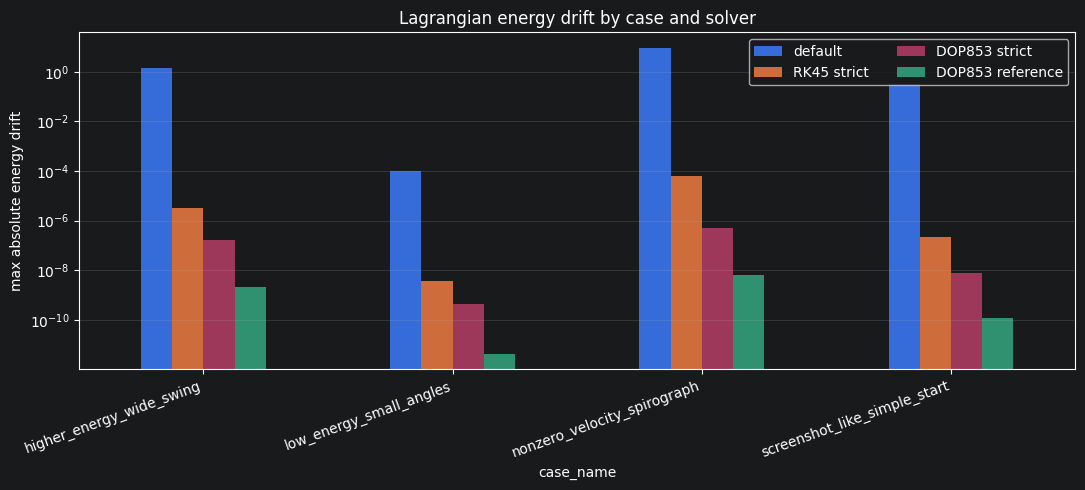

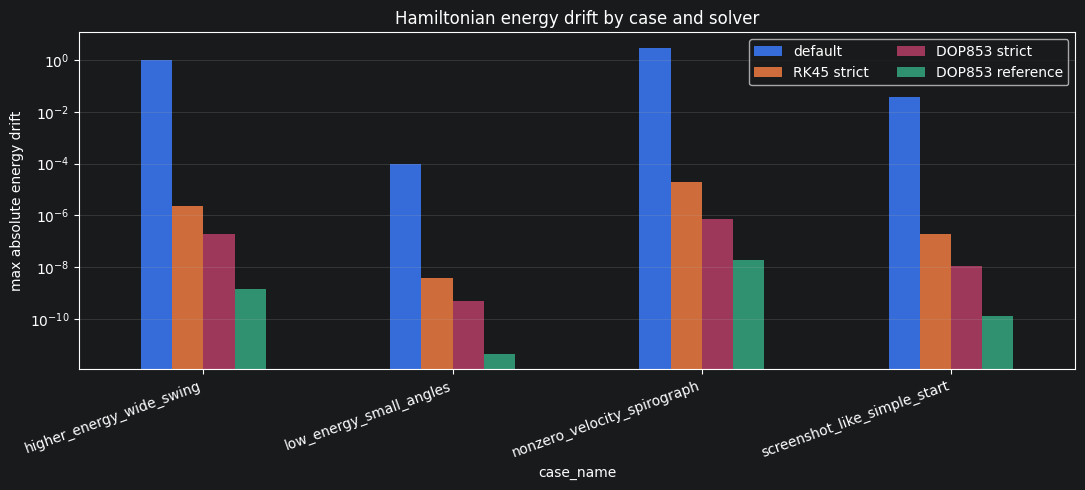

In [6]:
ordered_bar("lagrangian_max_abs_energy_drift", "max absolute energy drift", "Lagrangian energy drift by case and solver");
ordered_bar("hamiltonian_max_abs_energy_drift", "max absolute energy drift", "Hamiltonian energy drift by case and solver");

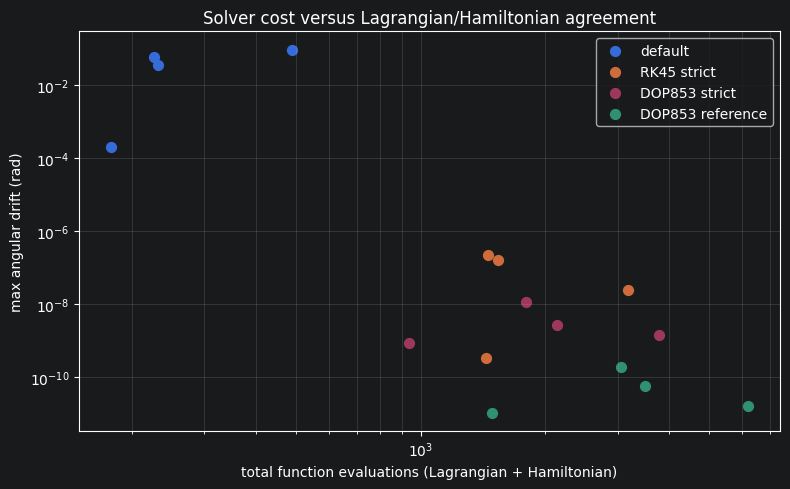

In [7]:
cost = runs.assign(total_nfev=runs["lagrangian_nfev"] + runs["hamiltonian_nfev"])
fig, ax = plt.subplots(figsize=(8, 5))
for solver, group in cost.groupby("solver_config", sort=False):
    ax.scatter(group["total_nfev"], group["max_abs_theta_diff_rad"], label=SOLVER_LABELS.get(solver, solver), s=50)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("total function evaluations (Lagrangian + Hamiltonian)")
ax.set_ylabel("max angular drift (rad)")
ax.set_title("Solver cost versus Lagrangian/Hamiltonian agreement")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.tight_layout();

## 4. Time-Series Visualisations

The long-format CSV lets us inspect when each run drifts, instead of looking only at end-state or maximum summaries.

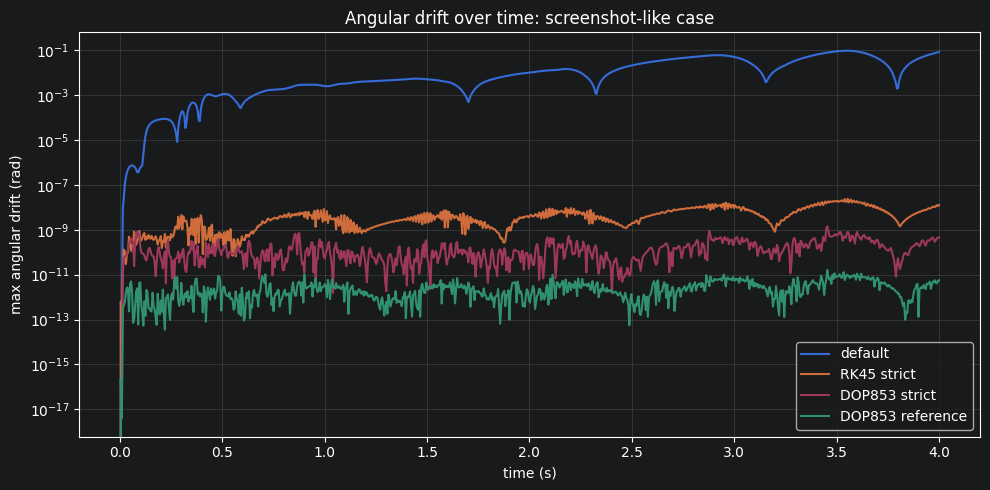

In [8]:
def plot_metric_over_time(case_name, metric, ylabel, title=None):
    subset = timeseries[timeseries["case_name"] == case_name]
    fig, ax = plt.subplots(figsize=(10, 5))
    for solver in SOLVER_ORDER:
        group = subset[subset["solver_config"] == solver]
        if group.empty:
            continue
        ax.plot(group["t"], group[metric], label=SOLVER_LABELS.get(solver, solver))
    ax.set_yscale("log")
    ax.set_xlabel("time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title or f"{metric} over time: {case_name}")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    return ax

plot_metric_over_time("screenshot_like_simple_start", "max_abs_theta_diff_rad", "max angular drift (rad)", "Angular drift over time: screenshot-like case");

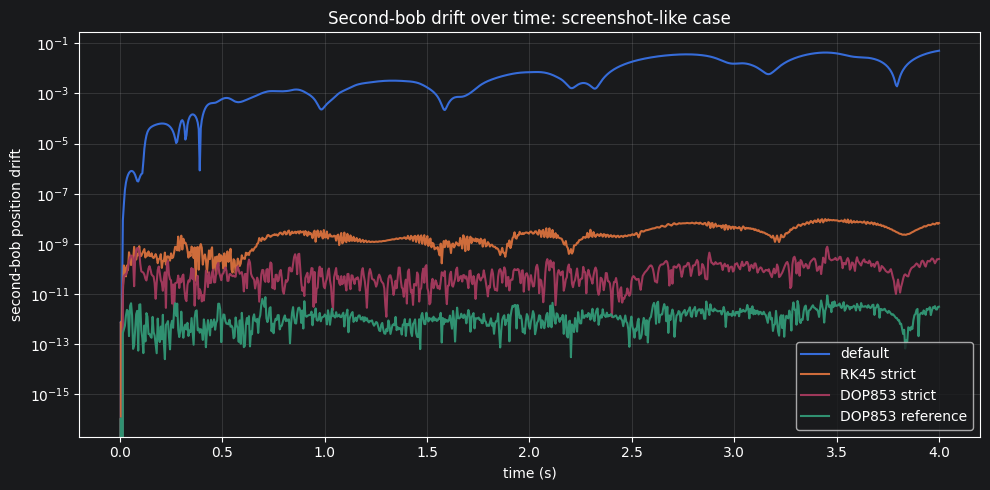

In [9]:
plot_metric_over_time("screenshot_like_simple_start", "second_bob_position_diff", "second-bob position drift", "Second-bob drift over time: screenshot-like case");

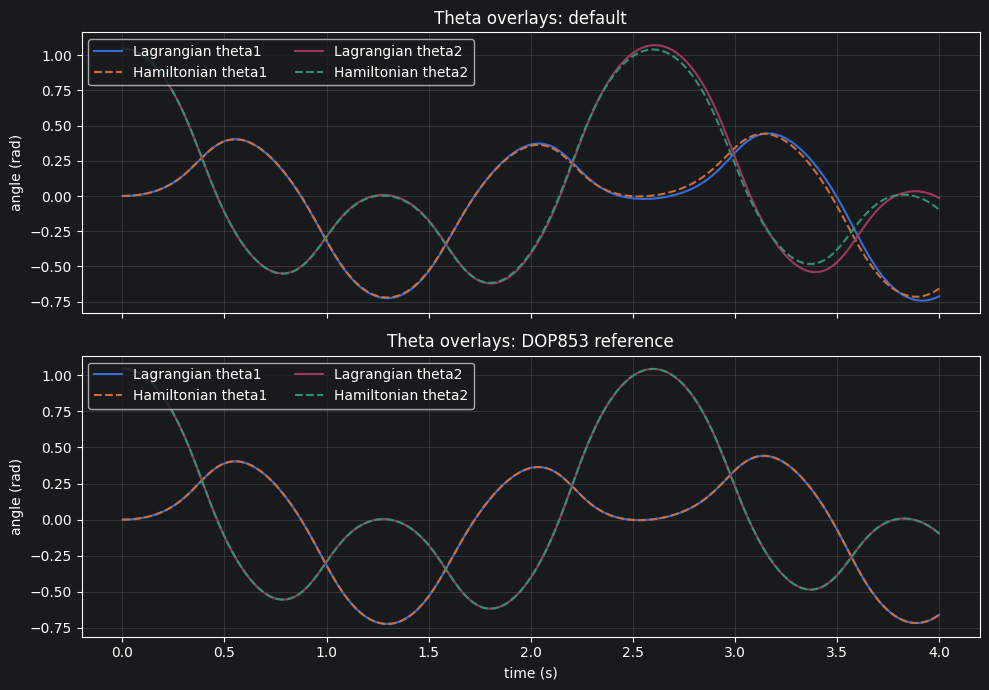

In [10]:
case_name = "screenshot_like_simple_start"
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, solver in zip(axes, ["solve_ivp_default", "dop853_reference"]):
    subset = timeseries[(timeseries["case_name"] == case_name) & (timeseries["solver_config"] == solver)]
    for theta in ("theta1", "theta2"):
        ax.plot(subset["t"], subset[f"lagrangian_{theta}_rad"], label=f"Lagrangian {theta}")
        ax.plot(subset["t"], subset[f"hamiltonian_{theta}_rad"], "--", label=f"Hamiltonian {theta}")
    ax.set_ylabel("angle (rad)")
    ax.set_title(f"Theta overlays: {SOLVER_LABELS[solver]}")
    ax.grid(True, alpha=0.25)
    ax.legend(ncols=2)
axes[-1].set_xlabel("time (s)")
plt.tight_layout();

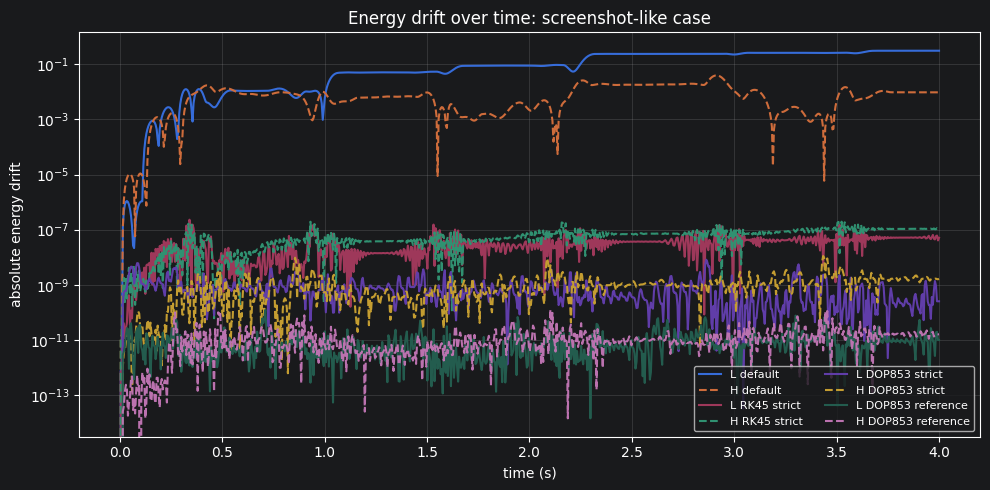

In [11]:
subset = timeseries[timeseries["case_name"] == "screenshot_like_simple_start"]
fig, ax = plt.subplots(figsize=(10, 5))
for solver in SOLVER_ORDER:
    group = subset[subset["solver_config"] == solver]
    ax.plot(group["t"], group["lagrangian_energy_abs_drift"], label=f"L {SOLVER_LABELS.get(solver, solver)}")
    ax.plot(group["t"], group["hamiltonian_energy_abs_drift"], "--", label=f"H {SOLVER_LABELS.get(solver, solver)}")
ax.set_yscale("log")
ax.set_xlabel("time (s)")
ax.set_ylabel("absolute energy drift")
ax.set_title("Energy drift over time: screenshot-like case")
ax.grid(True, which="both", alpha=0.25)
ax.legend(ncols=2, fontsize=8)
plt.tight_layout();

## 5. Focus: Screenshot-Like Simple Case `[0, 60, 0, 0]`

This section compares default solver behavior with the tight DOP853 reference configuration for the case that most closely matches the historical discrepancy note.

,solver_config,max_abs_theta_diff_rad,max_bob_position_abs_diff,lagrangian_max_abs_energy_drift,hamiltonian_max_abs_energy_drift,lagrangian_nfev,hamiltonian_nfev
4,solve_ivp_default,9.527861e-02,6.452911e-02,3.106289e-01,3.941292e-02,242,248
5,rk45_strict,2.432005e-08,1.465353e-08,2.290691e-07,1.940072e-07,1622,1562
6,dop853_strict,1.430321e-09,8.700129e-10,8.100578e-09,1.101330e-08,2045,1727
7,dop853_reference,1.611905e-11,9.556668e-12,1.219966e-10,1.270273e-10,3482,2723


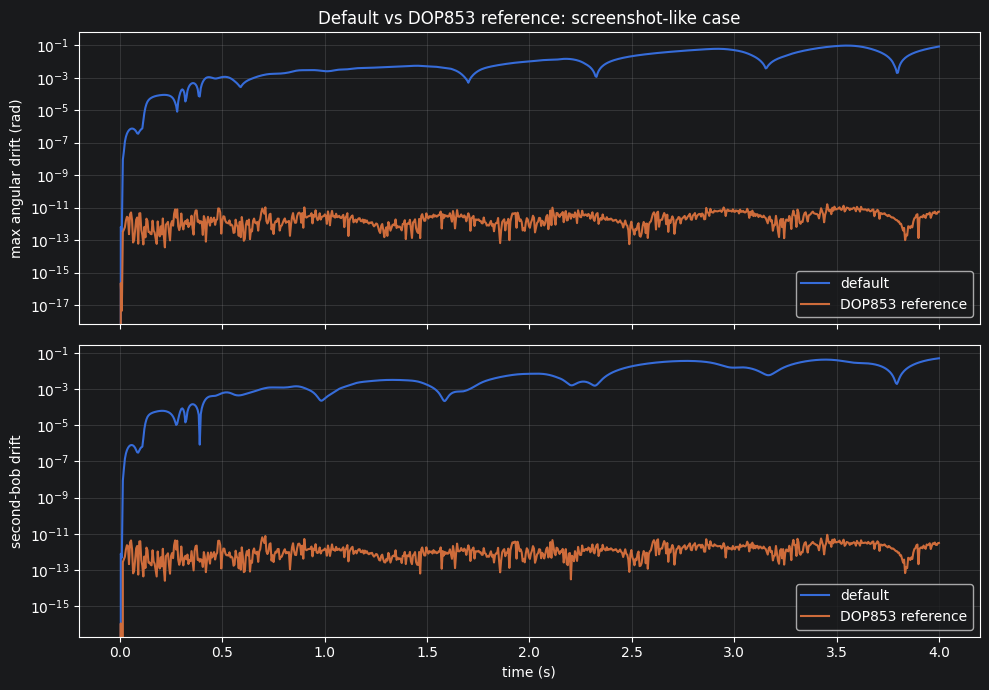

In [12]:
focus = timeseries[
    (timeseries["case_name"] == "screenshot_like_simple_start")
    & (timeseries["solver_config"].isin(["solve_ivp_default", "dop853_reference"]))
]
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for solver, group in focus.groupby("solver_config", sort=False):
    axes[0].plot(group["t"], group["max_abs_theta_diff_rad"], label=SOLVER_LABELS.get(solver, solver))
    axes[1].plot(group["t"], group["second_bob_position_diff"], label=SOLVER_LABELS.get(solver, solver))
axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[0].set_ylabel("max angular drift (rad)")
axes[1].set_ylabel("second-bob drift")
axes[1].set_xlabel("time (s)")
axes[0].set_title("Default vs DOP853 reference: screenshot-like case")
for ax in axes:
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.tight_layout()

runs[runs["case_name"].eq("screenshot_like_simple_start")][[
    "solver_config", "max_abs_theta_diff_rad", "max_bob_position_abs_diff",
    "lagrangian_max_abs_energy_drift", "hamiltonian_max_abs_energy_drift",
    "lagrangian_nfev", "hamiltonian_nfev"
]]

## 6. Divergence Thresholds

Compute the first logged time each run crosses practical angular-drift thresholds. `NaN` means the run never crossed that threshold in the logged interval.

In [13]:
thresholds = [1e-6, 1e-4, 1e-2]
rows = []
for (case_name, solver_config), group in timeseries.groupby(["case_name", "solver_config"]):
    row = {"case_name": case_name, "solver_config": solver_config}
    for threshold in thresholds:
        crossed = group[group["max_abs_theta_diff_rad"] >= threshold]
        row[f"first_crossing_{threshold:g}_s"] = crossed["t"].iloc[0] if not crossed.empty else np.nan
    rows.append(row)
threshold_table = pd.DataFrame(rows).sort_values(["case_name", "solver_config"])
display(threshold_table)

,case_name,solver_config,first_crossing_1e-06_s,first_crossing_0.0001_s,first_crossing_0.01_s
0,higher_energy_wide_swing,dop853_reference,NaN,NaN,NaN
1,higher_energy_wide_swing,dop853_strict,NaN,NaN,NaN
2,higher_energy_wide_swing,rk45_strict,NaN,NaN,NaN
3,higher_energy_wide_swing,solve_ivp_default,0.063439,0.093489,0.570952
4,low_energy_small_angles,dop853_reference,NaN,NaN,NaN
5,low_energy_small_angles,dop853_strict,NaN,NaN,NaN
6,low_energy_small_angles,rk45_strict,NaN,NaN,NaN
7,low_energy_small_angles,solve_ivp_default,0.110138,1.506884,NaN
8,nonzero_velocity_spirograph,dop853_reference,NaN,NaN,NaN
9,nonzero_velocity_spirograph,dop853_strict,NaN,NaN,NaN


## 7. Static Figures

Static PNG generation is optional and disabled by default. The notebook displays plots inline; committed PNG artifacts are not required evidence.

In [14]:
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Figure saving enabled: {FIGURE_DIR}")
else:
    print("Figure saving disabled. Use inline notebook plots as the inspection surface.")

sorted(FIGURE_DIR.glob("*.png")) if FIGURE_DIR.exists() else []

Figure saving disabled. Use inline notebook plots as the inspection surface.


[PosixPath('/Users/Ian/Documents/Study/ComputerScience/Maxima/MS327/Python/Double_Pendulum_App/development/math_fidelity/reports/figures/lagrangian_energy_drift_by_case_solver.png'),
 PosixPath('/Users/Ian/Documents/Study/ComputerScience/Maxima/MS327/Python/Double_Pendulum_App/development/math_fidelity/reports/figures/max_angular_drift_by_case_solver.png'),
 PosixPath('/Users/Ian/Documents/Study/ComputerScience/Maxima/MS327/Python/Double_Pendulum_App/development/math_fidelity/reports/figures/max_second_bob_position_drift.png'),
 PosixPath('/Users/Ian/Documents/Study/ComputerScience/Maxima/MS327/Python/Double_Pendulum_App/development/math_fidelity/reports/figures/screenshot_like_default_vs_reference_timeseries.png'),
 PosixPath('/Users/Ian/Documents/Study/ComputerScience/Maxima/MS327/Python/Double_Pendulum_App/development/math_fidelity/reports/figures/solver_cost_vs_accuracy.png')]

## 8. Optional Solver-Cost Benchmark Logs

If `solver_cost_benchmark.csv` exists, inspect it here. If it does not exist, the rest of the notebook still runs because the drift logs remain the source of truth for the drift investigation.

In [15]:
BENCHMARK_CSV = LOG_DIR / "solver_cost_benchmark.csv"

if BENCHMARK_CSV.exists():
    benchmark = pd.read_csv(BENCHMARK_CSV)
    print("benchmark rows/columns:", benchmark.shape)
    display(benchmark.head())
else:
    benchmark = None
    print("Benchmark log not found.")
    print("Generate it from the repository root with:")
    print(".venv/bin/python development/math_fidelity/probes/benchmark_solver_cost.py")

benchmark rows/columns: (160, 27)


,case_name,case_description,formulation,solver_config,solver_method,rtol,atol,duration_s,sample_count,sample_rate_hz,...,solver_success_all,solver_statuses,solver_messages,median_final_abs_energy_drift,median_max_abs_energy_drift,last_final_energy_drift,max_angular_drift_vs_reference_rad,initial_conditions_user_units,parameters,notes
0,low_energy_small_angles,Small angles released from rest; comparatively...,lagrangian,solve_ivp_default,solve_ivp_default,NaN,NaN,5,1000,200,...,True,"[""0""]","[""The solver successfully reached the end of t...",9.115457e-05,9.831912e-05,-9.115457e-05,NaN,"[5.0,7.0,0.0,0.0]","{""g"":9.81,""l1"":1.0,""l2"":1.0,""m1"":1.0,""m2"":1.0}",Current default solve_ivp behavior. Accuracy r...
1,low_energy_small_angles,Small angles released from rest; comparatively...,lagrangian,rk45_moderate,RK45,1.000000e-06,1.000000e-08,5,1000,200,...,True,"[""0""]","[""The solver successfully reached the end of t...",4.444624e-07,4.444624e-07,-4.444624e-07,NaN,"[5.0,7.0,0.0,0.0]","{""g"":9.81,""l1"":1.0,""l2"":1.0,""m1"":1.0,""m2"":1.0}",Moderate RK45 tolerance candidate. Accuracy re...
2,low_energy_small_angles,Small angles released from rest; comparatively...,lagrangian,rk45_strict,RK45,1.000000e-08,1.000000e-10,5,1000,200,...,True,"[""0""]","[""The solver successfully reached the end of t...",4.393236e-09,4.393236e-09,-4.393236e-09,NaN,"[5.0,7.0,0.0,0.0]","{""g"":9.81,""l1"":1.0,""l2"":1.0,""m1"":1.0,""m2"":1.0}",Strict RK45 tolerance candidate. Accuracy refe...
3,low_energy_small_angles,Small angles released from rest; comparatively...,lagrangian,dop853_moderate,DOP853,1.000000e-06,1.000000e-08,5,1000,200,...,True,"[""0""]","[""The solver successfully reached the end of t...",3.468278e-08,3.789742e-07,-3.468278e-08,NaN,"[5.0,7.0,0.0,0.0]","{""g"":9.81,""l1"":1.0,""l2"":1.0,""m1"":1.0,""m2"":1.0}",Moderate DOP853 tolerance candidate. Accuracy ...
4,low_energy_small_angles,Small angles released from rest; comparatively...,lagrangian,dop853_strict,DOP853,1.000000e-09,1.000000e-11,5,1000,200,...,True,"[""0""]","[""The solver successfully reached the end of t...",9.308110e-12,4.222009e-10,-9.308110e-12,NaN,"[5.0,7.0,0.0,0.0]","{""g"":9.81,""l1"":1.0,""l2"":1.0,""m1"":1.0,""m2"":1.0}",Strict DOP853 tolerance candidate. Accuracy re...


solver_config           dop853_moderate  dop853_strict  rk45_moderate  \
duration_s formulation                                                  
5          hamiltonian         0.041447       0.051745       0.039096   
           lagrangian          0.027939       0.038953       0.026771   
10         hamiltonian         0.051473       0.074060       0.048164   
           lagrangian          0.036781       0.059302       0.035366   
30         hamiltonian         0.098100       0.172872       0.089196   
           lagrangian          0.089423       0.150090       0.068170   
60         hamiltonian         0.160813       0.316692       0.149311   
           lagrangian          0.149520       0.298362       0.118391   

solver_config           rk45_strict  solve_ivp_default  
duration_s formulation                                  
5          hamiltonian     0.052347           0.033457  
           lagrangian      0.036503           0.020947  
10         hamiltonian     0.070882           0.035817  
           lagrangian      0.054822           0.024049  
30         hamiltonian     0.161447           0.053485  
           lagrangian      0.128379           0.034575  
60         hamiltonian     0.302530           0.072582  
           lagrangian      0.246282           0.051559

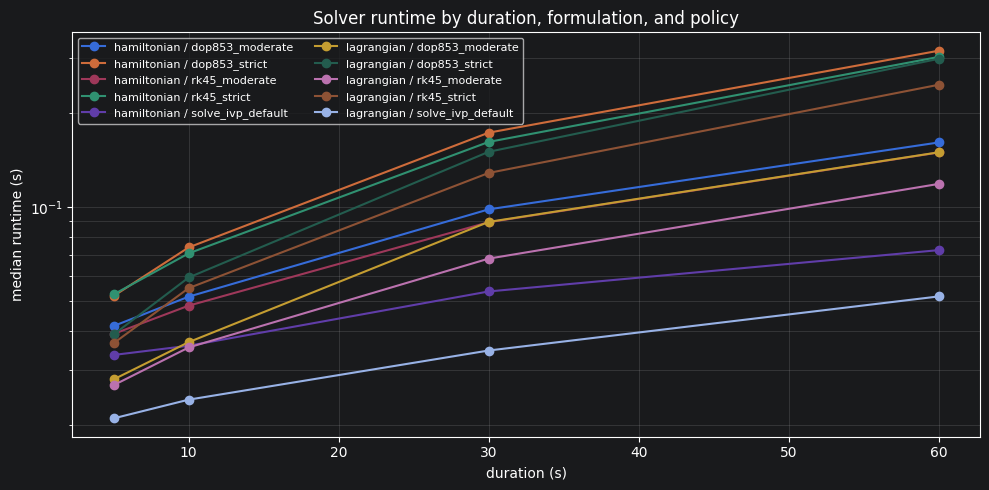

In [16]:
if benchmark is None:
    print("No benchmark log loaded.")
else:
    runtime_summary = benchmark.pivot_table(
        index=["duration_s", "formulation"],
        columns="solver_config",
        values="median_runtime_s",
        aggfunc="median",
    )
    display(runtime_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    for (formulation, solver_config), group in benchmark.groupby(["formulation", "solver_config"]):
        grouped = group.groupby("duration_s", as_index=False)["median_runtime_s"].median()
        ax.plot(grouped["duration_s"], grouped["median_runtime_s"], marker="o", label=f"{formulation} / {solver_config}")
    ax.set_yscale("log")
    ax.set_xlabel("duration (s)")
    ax.set_ylabel("median runtime (s)")
    ax.set_title("Solver runtime by duration, formulation, and policy")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8, ncols=2)
    plt.tight_layout();

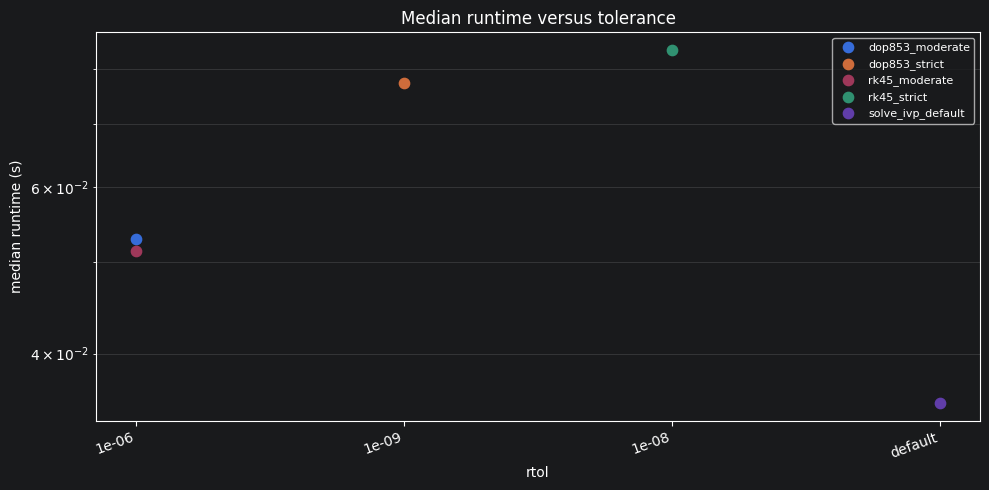

In [17]:
if benchmark is None:
    print("No benchmark log loaded.")
else:
    tolerant = benchmark.copy()
    tolerant["rtol_label"] = tolerant["rtol"].fillna("default").astype(str)
    fig, ax = plt.subplots(figsize=(10, 5))
    for solver_config, group in tolerant.groupby("solver_config"):
        grouped = group.groupby("rtol_label", as_index=False)["median_runtime_s"].median()
        ax.scatter(grouped["rtol_label"], grouped["median_runtime_s"], label=solver_config, s=55)
    ax.set_yscale("log")
    ax.set_xlabel("rtol")
    ax.set_ylabel("median runtime (s)")
    ax.set_title("Median runtime versus tolerance")
    ax.grid(True, axis="y", which="both", alpha=0.25)
    ax.legend(fontsize=8)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout();

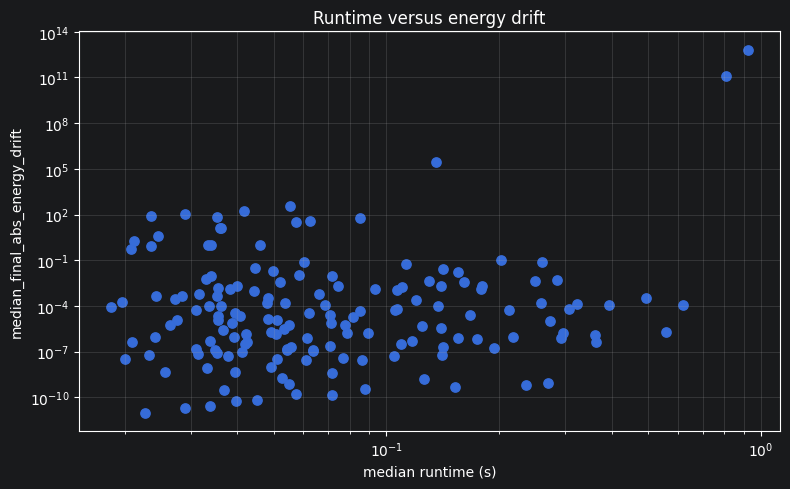

In [18]:
if benchmark is None:
    print("No benchmark log loaded.")
else:
    energy_cols = [c for c in benchmark.columns if c in ("median_max_abs_energy_drift", "median_final_abs_energy_drift")]
    if not energy_cols:
        print("Benchmark log does not include energy-drift columns.")
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        metric = energy_cols[0]
        ax.scatter(benchmark["median_runtime_s"], benchmark[metric], s=45)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("median runtime (s)")
        ax.set_ylabel(metric)
        ax.set_title("Runtime versus energy drift")
        ax.grid(True, which="both", alpha=0.25)
        plt.tight_layout();

In [19]:
if benchmark is None:
    print("No benchmark log loaded.")
else:
    app_relevant = benchmark[
        (benchmark["duration_s"] == 60)
        & (benchmark["sample_rate_hz"] == 200)
        & (benchmark["solver_method"].isin(["RK45", "DOP853"]))
    ]
    display(app_relevant[[
        "case_name", "formulation", "solver_config", "median_runtime_s",
        "median_nfev", "median_max_abs_energy_drift"
    ]].sort_values(["case_name", "formulation", "solver_config"]))

    comparison = app_relevant.pivot_table(
        index=["case_name", "formulation"],
        columns="solver_config",
        values="median_runtime_s",
        aggfunc="median",
    )
    display(comparison)

,case_name,formulation,solver_config,median_runtime_s,median_nfev,median_max_abs_energy_drift
158,higher_energy_wide_swing,hamiltonian,dop853_moderate,0.179553,15602.0,3.410595e-03
159,higher_energy_wide_swing,hamiltonian,dop853_strict,0.363274,35339.0,2.073637e-06
156,higher_energy_wide_swing,hamiltonian,rk45_moderate,0.161109,12566.0,3.657449e-03
157,higher_energy_wide_swing,hamiltonian,rk45_strict,0.307906,27434.0,9.854129e-05
153,higher_energy_wide_swing,lagrangian,dop853_moderate,0.179157,19526.0,3.340745e-03
154,higher_energy_wide_swing,lagrangian,dop853_strict,0.360784,43325.0,1.334335e-06
151,higher_energy_wide_swing,lagrangian,rk45_moderate,0.130098,14240.0,4.703246e-03
152,higher_energy_wide_swing,lagrangian,rk45_strict,0.274439,31010.0,1.580554e-05
38,low_energy_small_angles,hamiltonian,dop853_moderate,0.061195,2573.0,1.201268e-06
39,low_energy_small_angles,hamiltonian,dop853_strict,0.087811,5816.0,8.317684e-10


solver_config                             dop853_moderate  dop853_strict  \
case_name                    formulation                                   
higher_energy_wide_swing     hamiltonian         0.179553       0.363274   
                             lagrangian          0.179157       0.360784   
low_energy_small_angles      hamiltonian         0.061195       0.087811   
                             lagrangian          0.041941       0.071734   
nonzero_velocity_spirograph  hamiltonian         0.285134       0.620368   
                             lagrangian          0.260842       0.559701   
screenshot_like_simple_start hamiltonian         0.142073       0.270110   
                             lagrangian          0.119883       0.235941   

solver_config                             rk45_moderate  rk45_strict  
case_name                    formulation                              
higher_energy_wide_swing     hamiltonian       0.161109     0.307906  
                             lagrangian        0.130098     0.274439  
low_energy_small_angles      hamiltonian       0.077368     0.140755  
                             lagrangian        0.054893     0.104942  
nonzero_velocity_spirograph  hamiltonian       0.249926     0.494081  
                             lagrangian        0.202066     0.393907  
screenshot_like_simple_start hamiltonian       0.137513     0.297154  
                             lagrangian        0.106685     0.218124

## 9. Interpretation

The plots make the same pattern visible from several angles: default `solve_ivp` can produce substantial Lagrangian/Hamiltonian disagreement for the simple model, while strict RK45 and DOP853 configurations collapse that drift by many orders of magnitude. Position drift and energy drift follow the same broad tolerance pattern.

The evidence remains scoped: these logs cover short simple-model runs only. They support solver/tolerance sensitivity as the main explanation for the observed simple-model drift, but they do not settle compound-model fidelity, long-duration chaotic validity, or production solver-policy decisions.